### Libraries Load

In [2]:
%%capture
%pip install -r requirements.txt 

In [3]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'

In [4]:
# =========================
# Standard library imports
# =========================
import os
import sys
import re
import random
from pathlib import Path
import math, json
import os, csv, gc, time
import warnings
warnings.filterwarnings("ignore")

# =========================
# ML/DL libraries
# =========================
import tensorflow as tf
from keras.utils import plot_model
from keras.utils import pad_sequences
from scipy import optimize

# =========================
# Explainability libraries
# =========================
from timeshap.explainer import local_event
import google.generativeai as genai

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Plotting libraries
# =========================
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import seaborn as sns
import ecg_plot
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, roc_curve
import plotly.graph_objects as go

# =========================
# Project-specific paths
# =========================

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\notebooks\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))
import physionet_challenge_utility_script_patched_v2 as pc

lime_xai_path = r"...\notebooks\lime_xai.py"
sys.path.append(os.path.dirname(lime_xai_path))
from lime_xai import lime_local

tf_xai_eval_rnn_path = r"...\notebooks\tf_xai_eval_rnn.py"
sys.path.append(os.path.dirname(tf_xai_eval_rnn_path))
from tf_xai_eval_rnn import TFAttribution, TFMetrics

ecg_multilabel_eval_path = r"...\notebooks\ecg_multilabel_eval.py"
sys.path.append(os.path.dirname(ecg_multilabel_eval_path))
from ecg_multilabel_eval import compute_per_class_metrics, plot_roc_for_top_k

# =========================
# (Optional) Jupyter autoreload
# =========================
%load_ext autoreload
%autoreload 2


In [5]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)

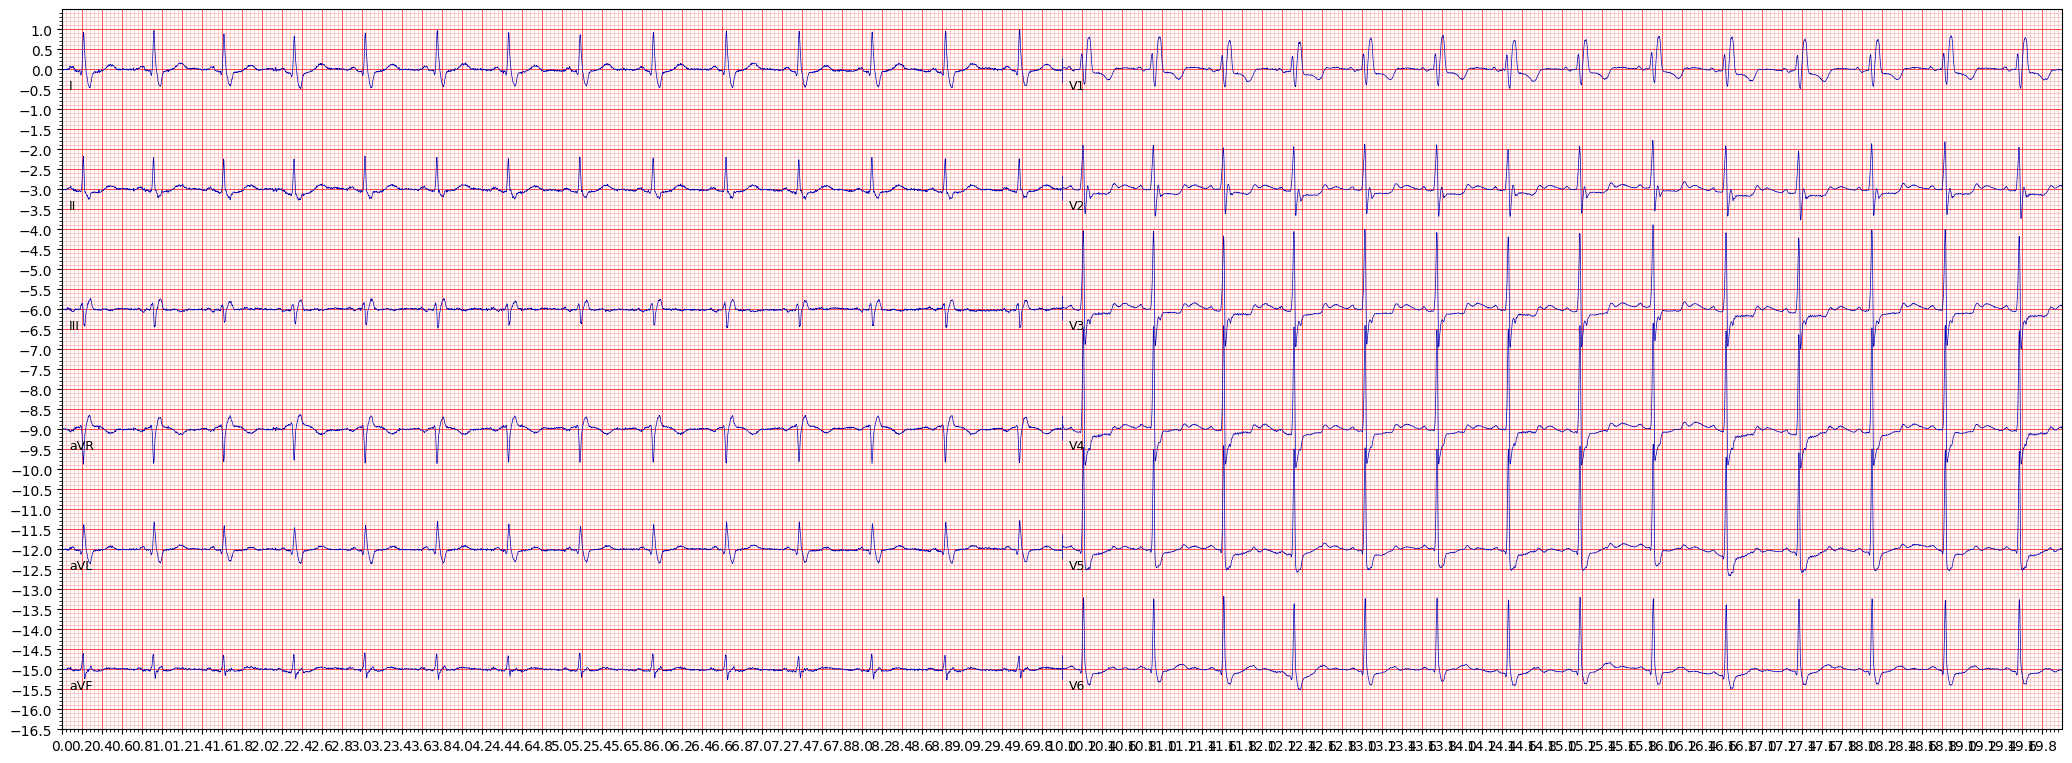

In [6]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [7]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [8]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if  want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if  prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [9]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [10]:
sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [11]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [12]:
df_labels

,0
0,"undefined class,427084000"
1,undefined class
2,"undefined class,undefined class"
3,"undefined class,undefined class"
4,undefined class
...,...
43096,"undefined class,undefined class,undefined class"
43097,"undefined class,undefined class,427084000,unde..."
43098,"undefined class,undefined class,426627000,6359..."
43099,"undefined class,427084000,undefined class,unde..."


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [13]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [14]:
y.shape

(43101, 27)

In [15]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

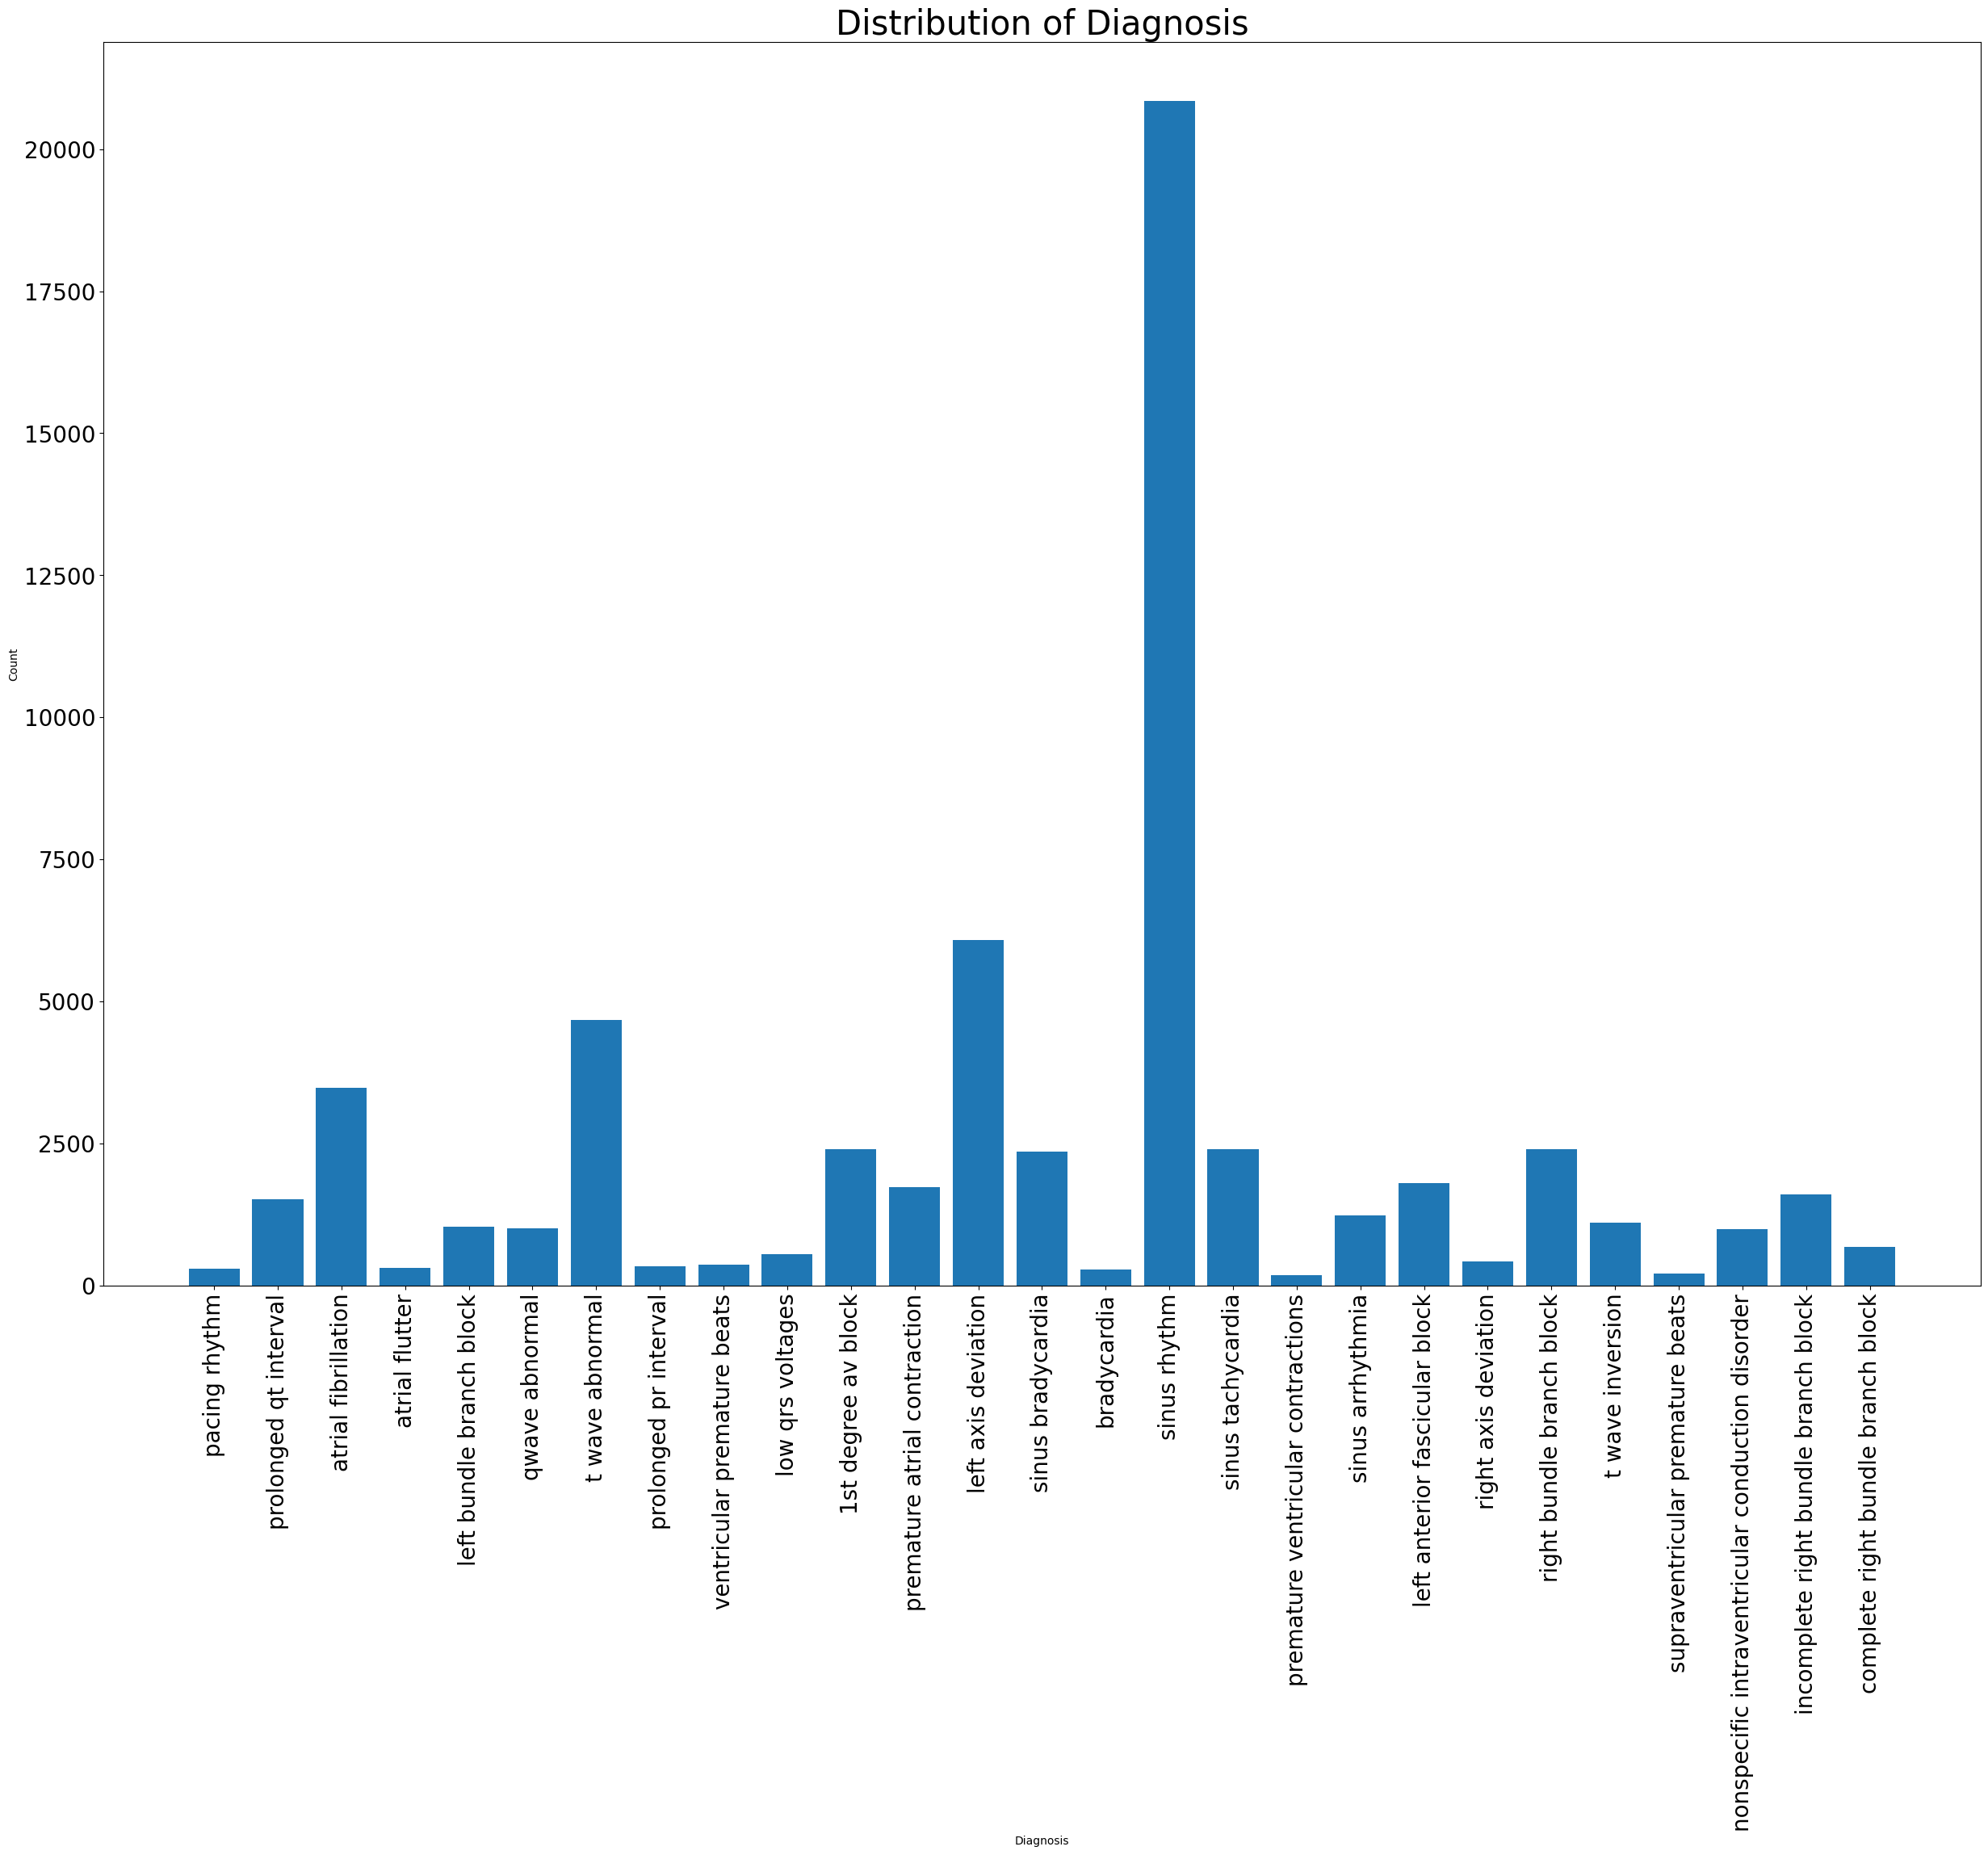

In [16]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [17]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [18]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


### Results

#### Residual Neural Network

In [19]:
model = pc.residual_network_1d()

load a pre-trained model - trained parameters (weights & biases)

In [20]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

In [21]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 107s 787ms/step


In [22]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


In [23]:
y_pred.shape

(4311, 27)

In [24]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

## LIME Class implementation

In [25]:
import itertools
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression

class Lime_Implementation:
    def __init__(self,model,data,num_perturbations: int,window_size:int, kernel_width=0.25):
        self.model = model
        self.data = data
        self.num_perturbations = num_perturbations
        self.window_size = window_size
        self.kernel_width = kernel_width
        self.num_features = data.shape[2]
        if len(data.shape) != 3:
            raise ValueError("input Data must be batch of instance")

    def _kernel_func(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / self.kernel_width ** 2))

    def _instance_feature_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,self.num_features)
        perturb_instance_predictions = np.array([model.predict(subset * instance) for subset in perturbations_sets])
        original_instance = np.ones(self.num_features)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_instance_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]
    
    def _instance_event_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        num_events = int(np.ceil(instance.shape[1] / self.window_size))
        events = list(self._create_event_chunks(instance[0].copy(),num_events))
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,num_events)
        perturb_events_predictions = []
        for subset in perturbations_sets:
            perturb_events = np.array(list(map(lambda x:x[0] * x[1], zip(events,subset))))
            perturb_events_predictions.append(model.predict(perturb_events))
        perturb_events_predictions = np.array(perturb_events_predictions)
        original_instance = np.ones(num_events)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_events_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]

    def feature_explain(self):
        return np.array(list(map(self._instance_feature_explain,self.data)))
    
    def event_explain(self):
        return np.array(list(map(self._instance_event_explain,self.data)))
    
    @staticmethod
    def _create_perturbations_sets(m: int, n: int):
        perturbations_sets = list(map(list, itertools.product([0, 1], repeat=n)))
        if m==-1 or m==2**n:
            return np.array(perturbations_sets)
        random_index = np.random.choice(len(perturbations_sets), m, replace=False)
        random_perturbations_sets = [perturbations_sets[i] for i in random_index]
        return np.array(random_perturbations_sets)


    @staticmethod
    def _create_event_chunks(instance, num_chunks: int):
        for i in range(0, len(instance), num_chunks):
            yield instance[i:i+num_chunks]   


In [ ]:
lime_explanation = Lime_Implementation(model, 
                                        sample, 
                                        num_perturbations=200, 
                                        window_size=500)

In [27]:
lime_explanation.feature_explain()

1/1 [==============================] - 0s 52ms/step


array([[ 4.03680953e-02,  3.48400865e-02,  1.02803020e-01,
         2.91915690e-02,  2.24432521e-02,  7.01386640e-02,
         4.55948677e-02,  2.87100956e-02,  1.18523807e-01,
         3.35467175e-02,  7.48385252e-02,  8.27881723e-02],
       [-9.09728472e-03, -1.76164054e-03, -1.41499060e-02,
         7.61629336e-03,  5.88877308e-03,  1.06163088e-02,
         2.28957552e-03,  8.71686120e-03, -4.53851225e-03,
         7.13919724e-03,  7.65523931e-03,  1.49902607e-03],
       [-5.77720197e-03, -1.90605402e-03,  7.37123111e-03,
         1.09015770e-02,  4.36977582e-03,  1.75465515e-02,
        -8.58566016e-03,  8.16691958e-03, -4.34618718e-04,
         1.23315719e-02,  9.44819015e-04,  5.37336768e-03],
       [-5.53668434e-04, -5.01322796e-04, -1.34174935e-03,
         6.28229319e-04, -8.73167265e-04,  7.45215726e-04,
        -1.10388222e-03,  2.02116956e-04, -6.09760480e-04,
         8.30511281e-04,  6.59294220e-04,  1.80329151e-04],
       [ 1.27199692e-02,  5.53447222e-02,  1.8527417

In [28]:
lime_explanation.event_explain()

1/1 [==============================] - 0s 30ms/step


array([[-8.13917504e-05, -9.90458721e-20,  7.01419831e-20,
         4.89739790e-20,  7.05514782e-20, -2.04269487e-20,
        -6.16763592e-20,  1.27208912e-20, -2.45328449e-20,
        -4.60492056e-20],
       [-2.13852551e-01,  2.59132651e-17, -4.79657383e-17,
        -5.05549754e-18, -1.21552575e-16,  1.04403213e-16,
         4.22947232e-17,  7.49829806e-17,  5.80591462e-17,
         1.20648444e-17],
       [ 3.54288518e-03, -9.94741701e-19, -4.61383458e-19,
         3.20936112e-19,  1.22103856e-18, -2.92003478e-19,
         3.91234348e-19,  4.62041593e-19,  5.55279270e-19,
        -3.26670837e-19],
       [ 7.75011750e-02,  9.18358897e-18,  1.55416620e-17,
        -1.06613063e-17,  7.37830302e-19, -1.34493178e-17,
         3.75423507e-17, -9.71465859e-18, -9.24444453e-18,
        -2.54250850e-17],
       [ 4.40487154e-02, -4.81164429e-18, -2.60200946e-18,
         9.06563537e-19, -2.04210055e-18,  3.30125914e-18,
         1.52234478e-17,  4.49144922e-19, -2.01012580e-18,
         6.

In [29]:
sample_prediction = model.predict(sample)
top_lime_classes = sample_prediction[0].argsort()

top_lime_classes

1/1 [==============================] - 0s 309ms/step


array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [30]:
num_perturbations = 200
num_feature = 12

perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[1, 1, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1],
       ...,
       [1, 0, 0, ..., 0, 1, 1],
       [1, 0, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0]])

In [31]:
perturb_prediction = []
distance = []

for subset in perturbations:
    data = sample * subset
    perturb_prediction.append(model.predict(data))

perturb_prediction = np.array(perturb_prediction)
perturb_prediction.shape

1/1 [==============================] - 0s 275ms/step


(200, 10, 27)

In [32]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [33]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [48]:
top_lime_classes

array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [ ]:
class_to_explain = top_lime_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([-0.00659534,  0.09099585,  0.10201836,  0.04267212,  0.08176355,
        0.00706136,  0.02189597,  0.00927388,  0.07643816,  0.06089287,
        0.0521524 ,  0.0240916 ])

In [59]:
class_to_explain = top_lime_classes[-1]

In [35]:
import plotly.express as px


Coeff_df = pd.DataFrame()

Coeff_df['TELMI'] = coeff

fig = px.bar(Coeff_df, x=Coeff_df['TELMI'], y= Coeff_df.index, orientation='h', color=Coeff_df.index)
fig.show()

Sub LIME class

## Predictor

Group the predictions and get two different files with the same prediction by the model.

In [94]:
val_idx = folds[0][1]
X_val, y_val = pc.generate_validation_data(ecg_filenames, y, val_idx)
filenames_val = ecg_filenames[val_idx]

def _predict_probs(model, X_val):
    """Works for single- or multi-input Keras models."""
    if isinstance(X_val, (list, tuple)):
        return model.predict(X_val, verbose=0)
    else:
        return model.predict(X_val, verbose=0)

probs_val = _predict_probs(model, X_val)  # shape: (N_val, 27)

# Group K examples per class (TPs first, then top-prob extras) ---
def group_examples_per_class(y_true, y_prob, class_names, k_per_class=2, thresholds=None):
    C = y_prob.shape[1]
    assert C == y_true.shape[1] == len(class_names), "class dimension mismatch"
    th = np.full(C, 0.5) if thresholds is None else np.asarray(thresholds, float)
    y_hat = (y_prob >= th).astype(int)

    groups = {}
    for j, cname in enumerate(class_names):
        # true positives sorted by probability
        tp = np.where(y_true[:, j] == 1)[0]
        tp = tp[np.argsort(-y_prob[tp, j])]
        take = list(tp[:k_per_class])

        # top up with highest-prob remaining samples if needed
        if len(take) < k_per_class:
            need = k_per_class - len(take)
            order = np.argsort(-y_prob[:, j])
            extra = [i for i in order if i not in take][:need]
            take.extend(extra)

        groups[cname] = take
    return groups, y_hat

# --- 3) Human-friendly summary table ---
def make_selection_df(groups, y_true, y_prob, class_names, filenames):
    rows = []
    for cname, idxs in groups.items():
        for i in idxs:
            topk = np.argsort(-y_prob[i])[:5]
            rows.append({
                "group_class": cname,
                "val_idx": int(i),
                "filename": filenames[i],
                "true_labels": ",".join([class_names[k] for k in np.where(y_true[i]==1)[0]]),
                "top_pred": ",".join([f"{class_names[k]}({y_prob[i,k]:.2f})" for k in topk]),
            })
    return pd.DataFrame(rows).sort_values(["group_class", "val_idx"]).reset_index(drop=True)

class_names = snomed_classes
groups, yhat_bin = group_examples_per_class(y_val, probs_val, class_names=class_names, k_per_class=2)

sel_df = make_selection_df(groups, y_val, probs_val, class_names, filenames_val)
sel_df.to_csv("ecg_model_val_select.csv", index=False)

### LIME

In [97]:
import os, re, json, numpy as np, pandas as pd
from scipy.io import loadmat
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances

# ---------- header + MAT helpers ----------
def parse_fs_and_leads(hea_path, default_fs=500.0):
    fs, lead_names = float(default_fs), None
    if not os.path.exists(hea_path): return fs, lead_names
    try:
        with open(hea_path, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f if ln.strip()]
    except UnicodeDecodeError:
        with open(hea_path, "r", encoding="latin-1") as f:
            lines = [ln.strip() for ln in f if ln.strip()]
    if lines:
        m = re.match(r'^\s*\S+\s+(\d+)\s+([\d.]+)\s+(\d+)', lines[0])
        if m:
            fs = float(m.group(2))
            nL = int(m.group(1))
            if len(lines) >= 1 + nL:
                lead_names = [lines[i].split()[-1] for i in range(1, 1 + nL)]
    return fs, lead_names

def ensure_paths(base):
    base = str(base)
    if base.endswith(".hea"):
        hea, mat = base, os.path.splitext(base)[0] + ".mat"
    elif base.endswith(".mat"):
        mat, hea = base, os.path.splitext(base)[0] + ".hea"
    else:
        b = os.path.splitext(base)[0]
        hea, mat = b + ".hea", b + ".mat"
    return hea, mat

def load_mat_TF(mat_path):
    d = loadmat(mat_path, squeeze_me=True)
    for k in ("val","ECG","ecg","data","signal"):
        if k in d:
            arr = np.asarray(d[k]); break
    else:
        raise ValueError(f"No ECG found in {mat_path}")
    if arr.ndim == 1: arr = arr[None, :]
    if arr.shape[0] in (8,12): x = arr.T
    elif arr.shape[1] in (8,12): x = arr
    else: x = arr.T if arr.shape[0] <= arr.shape[1] else arr
    return x.astype(np.float32, copy=False)

import numpy as np

def _lookup_class_index(class_names, class_key):
    """Return index of class_key in class_names (robust to ndarray/list and int/str types)."""
    arr = np.asarray(class_names).astype(str)
    key = str(class_key)
    idx = np.where(arr == key)[0]
    if len(idx) == 0:
        raise ValueError(f"class '{class_key}' not found in class_names")
    return int(idx[0])


# ---------- LIME core (compute-only) ----------
def _segments(T, win_samp):
    starts = np.arange(0, T, win_samp)
    return [(int(s), int(min(T, s + win_samp))) for s in starts]

def lime_events(model, x_tf, class_idx, win_samp, m_masks=200, kernel_width=0.25, rng=42):
    T, F = x_tf.shape
    segs = _segments(T, win_samp); E = len(segs)
    rng = np.random.default_rng(rng)
    M = rng.binomial(1, 0.5, size=(m_masks, E)).astype(np.float32); M[0,:] = 1
    time_mask = np.zeros((m_masks, T, 1), dtype=np.float32)
    for e, (s, t) in enumerate(segs): time_mask[:, s:t, 0] = M[:, e][:, None]
    base = np.zeros_like(x_tf)
    Xp = base[None, ...].repeat(m_masks, 0)
    Xp = np.where(time_mask == 1, x_tf[None, ...], Xp)
    y = model.predict(Xp, verbose=0)[:, class_idx]
    d = pairwise_distances(M, np.ones((1, E)), metric="cosine").ravel()
    w = np.sqrt(np.exp(-(d**2)/(kernel_width**2)))
    coef = Ridge(alpha=1e-2).fit(M, y, sample_weight=w).coef_.astype(np.float32)
    return coef, segs  # (E,), list[(s,t)]

def lime_features_in_event(model, x_tf, class_idx, seg, m_masks=200, kernel_width=0.25, mode="isolated", rng=42):
    T, F = x_tf.shape
    s, t = seg
    rng = np.random.default_rng(rng)
    M = rng.binomial(1, 0.5, size=(m_masks, F)).astype(np.float32); M[0,:] = 1
    if mode == "isolated":
        Xp = np.zeros((m_masks, T, F), dtype=np.float32)
        Xp[:, s:t, :] = x_tf[None, s:t, :] * M[:, None, :]
    else:
        Xp = x_tf[None, ...].repeat(m_masks, 0)
        Xp[:, s:t, :] = x_tf[None, s:t, :] * M[:, None, :]
    y = model.predict(Xp, verbose=0)[:, class_idx]
    d = pairwise_distances(M, np.ones((1, F)), metric="cosine").ravel()
    w = np.sqrt(np.exp(-(d**2)/(kernel_width**2)))
    coef = Ridge(alpha=1e-2).fit(M, y, sample_weight=w).coef_.astype(np.float32)  # (F,)
    return coef

def run_lime_for_one_class(
    sel_df, class_name, *, model, X_val, class_names,
    window_sec=0.5, m_event=200, m_feat=200, topk_events=6,
    explain_class="force",     # 'force' (use class_name), 'pred' (use model argmax)
    mode="isolated", rng=42
):
    """
    sel_df rows must include: group_class, val_idx, filename.
    X_val is your (N_val, 5000, 12) preprocessed validation array (same order as filenames_val/y_val).
    class_names is the list of output names in model order (len 27).
    """
    assert "group_class" in sel_df.columns and "val_idx" in sel_df.columns and "filename" in sel_df.columns
    rows = sel_df[sel_df["group_class"] == class_name].copy()
    if rows.empty:
        raise ValueError(f"No rows in sel_df for class '{class_name}'")

    if explain_class == "force":
        c_force = _lookup_class_index(class_names, class_name)
    else:
        c_force = None
        
    out = []

    for _, r in rows.iterrows():
        i = int(r["val_idx"])
        hea_path, mat_path = ensure_paths(r["filename"])
        fs, lead_names = parse_fs_and_leads(hea_path, default_fs=500.0)

        # model-ready instance (5000x12) from your preprocessed validation set
        x_model = X_val[i]   # shape: (5000, 12)

        # pick class to explain
        if explain_class == "force":
            c = c_force
        elif explain_class == "pred":
            probs = model.predict(x_model[None, ...], verbose=0)[0]
            c = int(np.argmax(probs))
        else:
            raise ValueError("explain_class must be 'force' or 'pred'")

        # event LIME
        win_samp = max(1, int(round(window_sec * fs)))
        event_scores, segments = lime_events(model, x_model, c, win_samp, m_masks=m_event, rng=rng)

        # refine per-lead within top-K events
        topE = np.argsort(np.abs(event_scores))[::-1][:min(topk_events, len(segments))]
        perlead_spans = {j: [] for j in range(x_model.shape[1])}
        for e_idx in topE:
            coef_f = lime_features_in_event(model, x_model, c, segments[e_idx],
                                            m_masks=m_feat, mode=mode, rng=rng)
            s, t = segments[e_idx]
            for j in range(x_model.shape[1]):
                perlead_spans[j].append((int(s), int(t), float(coef_f[j])))

        # top-5 leads by |weight| sum across refined events
        lead_scores = {j: sum(abs(w) for (_, _, w) in spans) for j, spans in perlead_spans.items()}
        top5 = sorted(lead_scores, key=lead_scores.get, reverse=True)[:5]
        spans_top5 = {int(j): perlead_spans[j] for j in top5}

        out.append({
            "group_class": class_name,
            "val_idx": i,
            "filename": r["filename"],
            "hea_path": hea_path, "mat_path": mat_path,
            "fs": float(fs),
            "window_sec": float(window_sec),
            "window_size_samples": int(win_samp),
            "num_segments": int(len(segments)),
            "target_class_explained": int(c),
            "event_importances_json": json.dumps([float(v) for v in event_scores]),
            "segments_json": json.dumps([[int(s), int(t)] for (s, t) in segments]),
            "top_events_idx_json": json.dumps([int(x) for x in list(topE)]),
            "top5_lead_idx_json": json.dumps([int(j) for j in top5]),
            "perlead_spans_top5_json": json.dumps({int(j): [(int(s), int(t), float(w)) for (s,t,w) in spans_top5[j]] for j in spans_top5}),
            "lead_names": ",".join(lead_names) if lead_names else None,
        })

    df_lime = pd.DataFrame(out).sort_values(["group_class", "val_idx"]).reset_index(drop=True)
    return df_lime


### TimeSHAP

In [101]:
import os, re, json, numpy as np, pandas as pd
from scipy.io import loadmat
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances

# =========================
# I/O HELPERS
# =========================
def ensure_paths(base):
    base = str(base)
    if base.endswith(".hea"):
        hea, mat = base, os.path.splitext(base)[0] + ".mat"
    elif base.endswith(".mat"):
        mat, hea = base, os.path.splitext(base)[0] + ".hea"
    else:
        b = os.path.splitext(base)[0]
        hea, mat = b + ".hea", b + ".mat"
    return hea, mat

def parse_fs_and_leads(hea_path, default_fs=500.0):
    fs, lead_names = float(default_fs), None
    if not os.path.exists(hea_path): return fs, lead_names
    try:
        with open(hea_path, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f if ln.strip()]
    except UnicodeDecodeError:
        with open(hea_path, "r", encoding="latin-1") as f:
            lines = [ln.strip() for ln in f if ln.strip()]
    if lines:
        m = re.match(r'^\s*\S+\s+(\d+)\s+([\d.]+)\s+(\d+)', lines[0])
        if m:
            fs = float(m.group(2))
            nL = int(m.group(1))
            if len(lines) >= 1 + nL:
                lead_names = [lines[i].split()[-1] for i in range(1, 1 + nL)]
    return fs, lead_names

def load_mat_TF(mat_path):
    d = loadmat(mat_path, squeeze_me=True)
    for k in ("val","ECG","ecg","data","signal"):
        if k in d:
            arr = np.asarray(d[k]); break
    else:
        raise ValueError(f"No ECG found in {mat_path}")
    if arr.ndim == 1: arr = arr[None, :]
    if arr.shape[0] in (8,12): x = arr.T
    elif arr.shape[1] in (8,12): x = arr
    else: x = arr.T if arr.shape[0] <= arr.shape[1] else arr
    return x.astype(np.float32, copy=False)

# =========================
# KERNELSHAP CORE (TimeSHAP-like)
# =========================
def _segments(T, win_samp):
    starts = np.arange(0, T, win_samp)
    return [(int(s), int(min(T, s + win_samp))) for s in starts]

def _sample_masks_stratified(rng, D, m_total):
    """
    Stratify masks by coalition size to stabilize KernelSHAP.
    Includes all-ones; optionally includes all-zeros when available.
    """
    sizes = np.arange(0, D+1)
    # allocate roughly equal per size
    per = max(1, m_total // len(sizes))
    masks = []
    for k in sizes:
        if k == 0:
            m = 1  # include one all-zeros coalition
            z = np.zeros((m, D), dtype=np.float32)
            masks.append(z)
            continue
        if k == D:
            m = 1  # include one all-ones coalition
            o = np.ones((m, D), dtype=np.float32)
            masks.append(o)
            continue
        m = per
        M = np.zeros((m, D), dtype=np.float32)
        for i in range(m):
            idx = rng.choice(D, size=k, replace=False)
            M[i, idx] = 1.0
        masks.append(M)
    M = np.vstack(masks)
    return M

def _shap_kernel_weights(mask_matrix):
    """
    SHAP kernel: w(z) = (D-1)/(C*(D-C)), with large weights for C in {0, D}.
    """
    M = mask_matrix
    D = M.shape[1]
    C = M.sum(axis=1).astype(np.int32)
    w = np.empty(len(C), dtype=np.float64)
    # large but finite for extremes
    w[(C == 0) | (C == D)] = 1000.0
    mid = (C > 0) & (C < D)
    w[mid] = (D - 1.0) / (C[mid] * (D - C[mid]))
    return w

def _apply_time_masks(x_tf, masks_time, segments):
    """
    x_tf: (T,F), masks_time: (m, E) -> returns Xp: (m, T, F)
    Coalition = 1 keeps original window; 0 -> baseline (zeros).
    """
    T, F = x_tf.shape
    m, E = masks_time.shape
    time_mask = np.zeros((m, T, 1), dtype=np.float32)
    for e,(s,t) in enumerate(segments):
        time_mask[:, s:t, 0] = masks_time[:, e][:, None]
    base = np.zeros_like(x_tf)
    Xp = np.broadcast_to(base, (m, T, F)).copy()
    Xp = np.where(time_mask == 1, x_tf[None, ...], Xp)
    return Xp

def _apply_feature_masks_in_window(x_tf, masks_feat, seg, mode="isolated"):
    """
    masks_feat: (m, F), seg: (s,t) -> Xp: (m, T, F)
    """
    T, F = x_tf.shape
    s, t = seg
    m = masks_feat.shape[0]
    if mode == "isolated":
        Xp = np.zeros((m, T, F), dtype=np.float32)
        Xp[:, s:t, :] = x_tf[None, s:t, :] * masks_feat[:, None, :]
    else:
        Xp = np.repeat(x_tf[None, ...], m, axis=0)
        Xp[:, s:t, :] = x_tf[None, s:t, :] * masks_feat[:, None, :]
    return Xp

def timeshap_events(model, x_tf, class_idx, fs, window_sec=0.5,
                    m_coalitions=200, rng=42, link="identity"):
    """
    Event-level TimeSHAP (KernelSHAP) over time windows.
    Returns: shap_vals (E,), segments list[(s,t)]
    """
    win_samp = max(1, int(round(window_sec * fs)))
    segments = _segments(x_tf.shape[0], win_samp)
    E = len(segments)

    rng = np.random.default_rng(rng)
    M = _sample_masks_stratified(rng, E, m_coalitions)            # (m,E)
    Xp = _apply_time_masks(x_tf, M, segments)                      # (m,T,F)
    f = model.predict(Xp, verbose=0)[:, class_idx]                 # (m,)

    if link == "logit":
        eps = 1e-6
        f = np.log((f + eps) / (1.0 - f + eps))

    w = _shap_kernel_weights(M)
    # Weighted linear regression (KernelSHAP). Include intercept.
    reg = Ridge(alpha=1e-3, fit_intercept=True)
    reg.fit(M, f, sample_weight=w)
    shap_vals = reg.coef_.astype(np.float32)  # (E,)
    return shap_vals, segments, win_samp

def timeshap_features_in_event(model, x_tf, class_idx, seg,
                                m_coalitions=200, rng=42, mode="isolated", link="identity"):
    """
    Feature-level TimeSHAP inside one window.
    Returns: shap_vals_feat (F,)
    """
    T, F = x_tf.shape
    rng = np.random.default_rng(rng)
    M = _sample_masks_stratified(rng, F, m_coalitions)            # (m,F)
    Xp = _apply_feature_masks_in_window(x_tf, M, seg, mode=mode)  # (m,T,F)
    f = model.predict(Xp, verbose=0)[:, class_idx]
    if link == "logit":
        eps = 1e-6
        f = np.log((f + eps) / (1.0 - f + eps))
    w = _shap_kernel_weights(M)
    reg = Ridge(alpha=1e-3, fit_intercept=True)
    reg.fit(M, f, sample_weight=w)
    shap_vals = reg.coef_.astype(np.float32)  # (F,)
    return shap_vals

# robust class-name lookup (works for ndarray/list/ints/strings)
def _lookup_class_index(class_names, class_key):
    arr = np.asarray(class_names).astype(str)
    key = str(class_key)
    idx = np.where(arr == key)[0]
    if len(idx) == 0:
        raise ValueError(f"class '{class_key}' not found in class_names")
    return int(idx[0])

# =========================
# RUN FOR ONE CLASS (compute-only; no plotting)
# =========================
def run_timeshap_for_one_class(
    sel_df, class_name, *,
    model, X_val, class_names,
    window_sec=0.5, m_event=200, m_feat=200, topk_events=6,
    explain_class="force",   # 'force' -> class_name; 'pred' -> model argmax per row
    mode="isolated", rng=42, link="identity"
):
    """
    sel_df rows: ['group_class','val_idx','filename'] (from your shortlist)
    X_val: (N_val, 5000, 12) validation tensor aligned with filenames.
    Returns DataFrame with JSON payloads for later plotting/analysis.
    """
    assert {"group_class","val_idx","filename"}.issubset(sel_df.columns)
    rows = sel_df[sel_df["group_class"] == class_name].copy()
    if rows.empty:
        raise ValueError(f"No rows in sel_df for class '{class_name}'")

    c_force = _lookup_class_index(class_names, class_name) if explain_class == "force" else None
    out = []

    for _, r in rows.iterrows():
        i = int(r["val_idx"])
        hea_path, mat_path = ensure_paths(r["filename"])
        fs, lead_names = parse_fs_and_leads(hea_path, default_fs=500.0)

        # model-ready instance from your preprocessed validation set
        x_model = X_val[i]  # (5000,12)

        # choose class to explain
        if explain_class == "force":
            c = c_force
        elif explain_class == "pred":
            probs = model.predict(x_model[None, ...], verbose=0)[0]
            c = int(np.argmax(probs))
        else:
            raise ValueError("explain_class must be 'force' or 'pred'")

        # --- Event TimeSHAP ---
        shap_e, segments, win_samp = timeshap_events(
            model, x_model, c, fs, window_sec=window_sec,
            m_coalitions=m_event, rng=rng, link=link
        )

        # --- refine per-lead inside top-K events ---
        topE = np.argsort(np.abs(shap_e))[::-1][:min(topk_events, len(segments))]
        perlead_spans = {j: [] for j in range(x_model.shape[1])}
        for e_idx in topE:
            shap_f = timeshap_features_in_event(
                model, x_model, c, segments[e_idx],
                m_coalitions=m_feat, rng=rng, mode=mode, link=link
            )  # (F,)
            s, t = segments[e_idx]
            for j in range(x_model.shape[1]):
                perlead_spans[j].append((int(s), int(t), float(shap_f[j])))

        # --- top-5 leads by |SHAP| sum across refined events ---
        lead_scores = {j: sum(abs(w) for (_, _, w) in spans) for j, spans in perlead_spans.items()}
        top5 = sorted(lead_scores, key=lead_scores.get, reverse=True)[:5]
        spans_top5 = {int(j): perlead_spans[j] for j in top5}

        out.append({
            "group_class": class_name,
            "val_idx": i,
            "filename": r["filename"],
            "hea_path": hea_path, "mat_path": mat_path,
            "fs": float(fs),
            "window_sec": float(window_sec),
            "window_size_samples": int(win_samp),
            "num_segments": int(len(segments)),
            "target_class_explained": int(c),

            # Event-level SHAP
            "timeshap_event_values_json": json.dumps([float(v) for v in shap_e]),
            "segments_json": json.dumps([[int(s), int(t)] for (s, t) in segments]),
            "top_events_idx_json": json.dumps([int(x) for x in list(topE)]),

            # Feature-level (top-5 leads only)
            "top5_lead_idx_json": json.dumps([int(j) for j in top5]),
            "perlead_timeshap_top5_json": json.dumps({int(j): [(int(s), int(t), float(w)) for (s,t,w) in spans_top5[j]] for j in spans_top5}),
            "lead_names": ",".join(lead_names) if lead_names else None,
            "link": link,
            "mode": mode
        })

    df_ts = pd.DataFrame(out).sort_values(["group_class", "val_idx"]).reset_index(drop=True)
    return df_ts


### Summary

In [104]:
import json, numpy as np, pandas as pd
from scipy.stats import pearsonr, spearmanr

# ---------- small helpers ----------
def _safe_json(x):
    if isinstance(x, (list, tuple)): return x
    return json.loads(x) if isinstance(x, str) and x else []

def _to_tuples(seg_list):
    return [tuple(map(int, s)) for s in seg_list]

def _align_events(segA, vecA, segB, vecB):
    """
    Align two event-importance vectors by (s,t) segment keys.
    Returns aligned arrays a, b over the intersection of segments.
    """
    segA = _to_tuples(segA); segB = _to_tuples(segB)
    mapA = {st:i for i,st in enumerate(segA)}
    mapB = {st:i for i,st in enumerate(segB)}
    common = [st for st in segA if st in mapB]
    if not common:
        return np.array([]), np.array([])
    a = np.array([vecA[mapA[st]] for st in common], float)
    b = np.array([vecB[mapB[st]] for st in common], float)
    return a, b

def _cosine(u, v):
    u = np.asarray(u, float); v = np.asarray(v, float)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu == 0 or nv == 0: return np.nan
    return float(np.dot(u, v) / (nu * nv))

def _pearson(u, v):
    if len(u) < 2: return np.nan
    r, _ = pearsonr(u, v); return float(r)

def _spearman(u, v):
    if len(u) < 2: return np.nan
    r, _ = spearmanr(u, v); return float(r)

def _topk_indices(vec, k):
    idx = np.argsort(-np.abs(vec))[:k]
    return set(map(int, idx))

def _jaccard(A, B):
    if not A and not B: return 1.0
    return len(A & B) / float(len(A | B)) if (A | B) else 0.0

def _sum_abs_perlead_from_spans(spans_dict, n_leads=12):
    """
    spans_dict: {lead_idx: [(s,t,w), ...]}
    Returns length-12 vector of sum(abs(w)) per lead.
    Missing leads → 0.
    """
    scores = np.zeros(n_leads, float)
    for j, spans in (spans_dict or {}).items():
        if spans:
            scores[int(j)] = sum(abs(w) for (_, _, w) in spans)
    return scores

def _perlead_temporal_vectors(spans_dict, seg_keys, n_leads=12):
    """
    Build per-lead vectors over event indices:
    For each lead j, x[j, e] = sum of weights for spans that equal segment e (by (s,t) key).
    """
    idx_by_seg = {st:i for i,st in enumerate(map(tuple, seg_keys))}
    E = len(idx_by_seg)
    X = np.zeros((n_leads, E), float)
    for j, spans in (spans_dict or {}).items():
        for (s,t,w) in spans:
            key = (int(s), int(t))
            if key in idx_by_seg:
                X[int(j), idx_by_seg[key]] += float(w)
    return X

# ---------- main comparator ----------
def compare_lime_timeshap_for_class(df_lime, df_ts, class_name, k_top_events=5, n_leads=12):
    """
    Expects df_lime & df_ts produced by the earlier pipelines, for the same class_name.
    Returns a metrics DataFrame (one row per val_idx) + an overall summary row.
    """
    # align rows by val_idx (and class if present)
    key_cols = ["val_idx"]
    if "group_class" in df_lime.columns and "group_class" in df_ts.columns:
        df_l = df_lime[df_lime["group_class"] == class_name].copy()
        df_t = df_ts[df_ts["group_class"] == class_name].copy()
    else:
        df_l, df_t = df_lime.copy(), df_ts.copy()

    merged = pd.merge(df_l, df_t, on=key_cols, suffixes=("_lime", "_ts"))
    if merged.empty:
        raise ValueError("No overlapping rows between LIME and TimeSHAP for this class.")

    rows = []
    for r in merged.itertuples(index=False):
        # --- event vectors ---
        evL = np.array(_safe_json(getattr(r, "event_importances_json")), float)
        sgL = _safe_json(getattr(r, "segments_json_lime"))
        evT = np.array(_safe_json(getattr(r, "timeshap_event_values_json")), float)
        sgT = _safe_json(getattr(r, "segments_json_ts"))

        a, b = _align_events(sgL, evL, sgT, evT)  # intersected segments
        ev_cos = _cosine(a, b)
        ev_pear = _pearson(a, b)
        ev_spear = _spearman(a, b)

        # top-K event overlap (by |score|)
        topL = _topk_indices(a, k_top_events) if len(a) else set()
        topT = _topk_indices(b, k_top_events) if len(b) else set()
        ev_topk_jacc = _jaccard(topL, topT)

        # --- per-lead overall (sum |w| across spans) ---
        spansL = json.loads(getattr(r, "perlead_spans_top5_json")) if "perlead_spans_top5_json" in merged.columns else {}
        spansT = json.loads(getattr(r, "perlead_timeshap_top5_json")) if "perlead_timeshap_top5_json" in merged.columns else {}
        lead_vec_L = _sum_abs_perlead_from_spans(spansL, n_leads=n_leads)
        lead_vec_T = _sum_abs_perlead_from_spans(spansT, n_leads=n_leads)
        lead_cos   = _cosine(lead_vec_L, lead_vec_T)
        lead_pear  = _pearson(lead_vec_L, lead_vec_T)
        lead_spear = _spearman(lead_vec_L, lead_vec_T)

        # top-5 lead overlap
        top5L = set(np.argsort(-lead_vec_L)[:5].tolist())
        top5T = set(np.argsort(-lead_vec_T)[:5].tolist())
        lead_top5_jacc = _jaccard(top5L, top5T)

        # --- per-lead temporal (per event) on intersected segments ---
        seg_inter = _to_tuples(sgL)
        if sgT:  # enforce intersection keys
            seg_inter = list(set(_to_tuples(sgL)) & set(_to_tuples(sgT)))
        X_L = _perlead_temporal_vectors(spansL, seg_inter, n_leads=n_leads)
        X_T = _perlead_temporal_vectors(spansT, seg_inter, n_leads=n_leads)

        # cosine per-lead (ignore all-zero rows)
        perlead_cos = []
        for j in range(n_leads):
            if np.linalg.norm(X_L[j]) == 0 and np.linalg.norm(X_T[j]) == 0:
                continue
            perlead_cos.append(_cosine(X_L[j], X_T[j]))
        perlead_cos_mean = float(np.nanmean(perlead_cos)) if perlead_cos else np.nan

        # IoU per-lead (mark >0 as active)
        perlead_iou = []
        for j in range(n_leads):
            a_bin = (X_L[j] != 0)
            t_bin = (X_T[j] != 0)
            inter = (a_bin & t_bin).sum()
            union = (a_bin | t_bin).sum()
            if union == 0:
                continue
            perlead_iou.append(inter / union)
        perlead_iou_mean = float(np.nanmean(perlead_iou)) if perlead_iou else np.nan

        rows.append({
            "val_idx": int(getattr(r, "val_idx")),
            "ev_cosine": ev_cos,
            "ev_pearson": ev_pear,
            "ev_spearman": ev_spear,
            "ev_topK_jaccard": ev_topk_jacc,
            "lead_cosine": lead_cos,
            "lead_pearson": lead_pear,
            "lead_spearman": lead_spear,
            "lead_top5_jaccard": lead_top5_jacc,
            "perlead_temporal_cosine_mean": perlead_cos_mean,
            "perlead_temporal_iou_mean": perlead_iou_mean,
            # (optional: carry filenames)
            "filename_lime": getattr(r, "filename_lime", None),
            "filename_ts": getattr(r, "filename_ts", None),
        })

    df_metrics = pd.DataFrame(rows).sort_values("val_idx").reset_index(drop=True)

    # overall summary row
    summary = {
        "val_idx": "MEAN",
        "ev_cosine": df_metrics["ev_cosine"].mean(),
        "ev_pearson": df_metrics["ev_pearson"].mean(),
        "ev_spearman": df_metrics["ev_spearman"].mean(),
        "ev_topK_jaccard": df_metrics["ev_topK_jaccard"].mean(),
        "lead_cosine": df_metrics["lead_cosine"].mean(),
        "lead_pearson": df_metrics["lead_pearson"].mean(),
        "lead_spearman": df_metrics["lead_spearman"].mean(),
        "lead_top5_jaccard": df_metrics["lead_top5_jaccard"].mean(),
        "perlead_temporal_cosine_mean": df_metrics["perlead_temporal_cosine_mean"].mean(),
        "perlead_temporal_iou_mean": df_metrics["perlead_temporal_iou_mean"].mean(),
    }
    df_metrics = pd.concat([df_metrics, pd.DataFrame([summary])], ignore_index=True)
    return df_metrics


In [117]:
# ====================== LIME / TimeSHAP → payload → plot ======================
import os, json, re, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import pandas as pd  # needed for pd.isna in payload_from_lime_row

# --- lead layout/colors (like your example) ---
LIMB   = ["I","II","III","aVR","aVL","aVF"]
VLEADS = ["V1","V2","V3","V4","V5","V6"]
DEFAULT_LEADS = LIMB + VLEADS
LEAD_COLOR = {
    "I":"#2F5597","II":"#E69138","III":"#38761D",
    "aVR":"#CC0000","aVL":"#674EA7","aVF":"#B45F06",
    "V1":"#A64D79","V2":"#6AA84F","V3":"#BF9000",
    "V4":"#3D85C6","V5":"#45818E","V6":"#741B47"
}

# ---------- helpers ----------
def _read_header_lines(hea_path: str):
    if not os.path.exists(hea_path): return []
    try:
        with open(hea_path, "r", encoding="utf-8") as f:
            return [ln.rstrip("\n") for ln in f]
    except UnicodeDecodeError:
        with open(hea_path, "r", encoding="latin-1") as f:
            return [ln.rstrip("\n") for ln in f]

def _infer_fs_from_header_lines(header_lines, default=500.0):
    if not header_lines: return float(default)
    toks = header_lines[0].split()
    for tok in toks:
        try:
            x = float(tok)
        except Exception:
            continue
        if 50 <= x <= 2000:
            return float(x)
    return float(default)

def _bands_from_label_centers(ax):
    centers = {}
    for t in ax.texts:
        name = t.get_text().strip()
        if name in DEFAULT_LEADS:
            _, y = t.get_position(); centers[name] = float(y)

    def _from(order):
        ys = [centers[n] for n in order]
        mids = [(ys[i] + ys[i+1]) / 2 for i in range(len(ys)-1)]
        top    = ys[0] + (ys[0] - ys[1]) / 2
        bottom = ys[-1] - (ys[-2] - ys[-1]) / 2
        edges = [top] + mids + [bottom]
        return {order[i]: (edges[i], edges[i+1]) for i in range(len(order))}

    bands = {}
    if all(n in centers for n in LIMB):   bands.update(_from(LIMB))
    if all(n in centers for n in VLEADS): bands.update(_from(VLEADS))
    if len(bands) < 12:  # fallback: equal spacing
        ymin, ymax = ax.get_ylim(); h = (ymax - ymin) / 12.0
        for i, n in enumerate(DEFAULT_LEADS):
            ymid = ymax - (i + 0.5) * h; pad = 0.48*h
            bands[n] = (ymid + pad, ymid - pad)
    return bands

def _clip(span, dom):
    s, e = span; a, b = dom
    s, e = max(s, a), min(e, b)
    return None if e <= s else (s, e)

def _choose_top5_from_scores(lead_scores, perlead_spans):
    if isinstance(lead_scores, dict) and lead_scores:
        return [k for k,_ in sorted(lead_scores.items(), key=lambda kv: kv[1], reverse=True)[:5]]
    return [k for k,_ in sorted(perlead_spans.items(), key=lambda kv: len(kv[1]), reverse=True)[:5]]

def _lead_names_from_row(row):
    ln = row.get("lead_names", None)
    if isinstance(ln, str) and "," in ln:
        return [x.strip() for x in ln.split(",")]
    return DEFAULT_LEADS[:]  # sane default

def _maybe_shift_to_column(spans, left_dom, right_dom, want_dom):
    """
    If spans (list[(s,e)]) are entirely in the other half, shift by ±column width
    so they land in the desired half (want_dom). Keeps order/length.
    """
    if not spans:
        return spans
    aL, bL = left_dom
    aR, bR = right_dom
    col_w  = bL - aL  # == bR - aR

    def _any_intersect(sp_list, dom):
        A, B = dom
        for s, e in sp_list:
            if e > A and s < B:
                return True
        return False

    want_is_left = (want_dom == left_dom)
    have_want    = _any_intersect(spans, want_dom)
    have_other   = _any_intersect(spans, (right_dom if want_is_left else left_dom))

    if (not have_want) and have_other:
        delta = (-col_w) if want_is_left else (+col_w)
        return [(s + delta, e + delta) for (s, e) in spans]
    return spans

# ---------- 1) Build a plotting payload from a LIME row ----------
def payload_from_lime_row(row, *, label_for_title=""):
    mat_path = row["mat_path"] if "mat_path" in row else os.path.splitext(str(row["filename"]))[0] + ".mat"
    hea_path = os.path.splitext(mat_path)[0] + ".hea"
    fs = float(row["fs"]) if "fs" in row and not pd.isna(row["fs"]) else _infer_fs_from_header_lines(_read_header_lines(hea_path), 500.0)
    segs = json.loads(row["segments_json"])
    T = max(int(t) for (_, t) in segs) if segs else int(round(10*fs))
    page_seconds = T / fs

    spans_top5 = json.loads(row["perlead_spans_top5_json"])
    lead_names = _lead_names_from_row(row)
    perlead_spans_sec, lead_scores = {}, {}
    for k, lst in spans_top5.items():
        j = int(k)
        L = lead_names[j] if j < len(lead_names) else f"ch{j}"
        spans_sec = [(s/fs, t/fs, float(w)) for (s,t,w) in lst]
        perlead_spans_sec[L] = spans_sec
        lead_scores[L] = sum(abs(w) for (_,_,w) in lst)
    top5 = [lead_names[j] for j in json.loads(row["top5_lead_idx_json"])] if "top5_lead_idx_json" in row else _choose_top5_from_scores(lead_scores, perlead_spans_sec)

    return {
        "mat_path": mat_path,
        "target_label": label_for_title,
        "method_label": "LIME",
        "page_seconds": page_seconds,
        "perlead_spans": perlead_spans_sec,
        "lead_scores": lead_scores,
        "top5_leads": top5
    }

# ---------- 2) Build a plotting payload from a TimeSHAP row ----------
def payload_from_timeshap_row(row, *, label_for_title=""):
    mat_path = row["mat_path"] if "mat_path" in row else os.path.splitext(str(row["filename"]))[0] + ".mat"
    hea_path = os.path.splitext(mat_path)[0] + ".hea"
    fs = float(row["fs"]) if "fs" in row and not pd.isna(row["fs"]) else _infer_fs_from_header_lines(_read_header_lines(hea_path), 500.0)
    segs = json.loads(row["segments_json"])
    T = max(int(t) for (_, t) in segs) if segs else int(round(10*fs))
    page_seconds = T / fs

    spans_top5 = json.loads(row["perlead_timeshap_top5_json"])
    lead_names = _lead_names_from_row(row)
    perlead_spans_sec, lead_scores = {}, {}
    for k, lst in spans_top5.items():
        j = int(k)
        L = lead_names[j] if j < len(lead_names) else f"ch{j}"
        spans_sec = [(s/fs, t/fs, float(w)) for (s,t,w) in lst]
        perlead_spans_sec[L] = spans_sec
        lead_scores[L] = sum(abs(w) for (_,_,w) in lst)
    top5 = [lead_names[j] for j in json.loads(row["top5_lead_idx_json"])] if "top5_lead_idx_json" in row else _choose_top5_from_scores(lead_scores, perlead_spans_sec)

    return {
        "mat_path": mat_path,
        "target_label": label_for_title,
        "method_label": "TimeSHAP",
        "page_seconds": page_seconds,
        "perlead_spans": perlead_spans_sec,
        "lead_scores": lead_scores,
        "top5_leads": top5
    }

# ---------- 3) The plotter (uses global pc and ecg_plot) ----------
def plot_from_payload(payload,
                      alpha_fill=0.35, alpha_min=0.18, edge_alpha=0.85,
                      tick_major_s=1.0, tick_minor_s=0.2,
                      figsize=(20, 6), raise_maxticks=True):
    """
    Draws paper ECG (2-column) then overlays the per-lead rectangles (page-seconds).
    Assumes `pc` and `ecg_plot` are already imported in your session.
    """
    # load ECG and Fs
    data_12xT, header_lines = pc.load_challenge_data(payload["mat_path"])
    hea_path = os.path.splitext(payload["mat_path"])[0] + ".hea"
    fs = _infer_fs_from_header_lines(_read_header_lines(hea_path), 500.0)

    # crop to the page used by the explainer
    page_sec = float(payload.get("page_seconds", 10.0))
    K = int(round(page_sec * fs))
    if data_12xT.shape[1] > K > 0:
        data_12xT = data_12xT[:, -K:]

    # plot waveform FIRST
    plt.figure(figsize=figsize)
    ecg_plot.plot(data_12xT / 1000.0, sample_rate=fs, title="")
    ax = plt.gca(); fig = plt.gcf()

    # grid/ticks
    if raise_maxticks:
        mticker.Locator.MAXTICKS = max(mticker.Locator.MAXTICKS, 10000)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_major_s))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(tick_minor_s))

    # per-row bands & left/right time domains
    bands = _bands_from_label_centers(ax)
    x0, x1 = ax.get_xlim()
    split = 0.5 * (x0 + x1)
    left_dom, right_dom = (x0, split), (split, x1)
    lead_dom = {L: left_dom for L in LIMB}
    lead_dom.update({L: right_dom for L in VLEADS})

    # decide top-5 and legend labels
    perlead_spans = payload["perlead_spans"]
    lead_scores   = payload.get("lead_scores", {})
    top5          = payload.get("top5_leads") or _choose_top5_from_scores(lead_scores, perlead_spans)

    # normalize legend scores (optional)
    score_text = {}
    if lead_scores:
        vals = np.array([lead_scores.get(L, 0.0) for L in top5], float)
        if np.all(vals >= 0) and np.any(vals > 0):
            vals = vals / (vals.sum() if vals.sum() != 0 else 1.0)
        score_text = {L: vals[i] for i, L in enumerate(top5)}

    # draw rectangles (BEHIND the trace) — with column shift fix
    handles = []
    for L in top5:
        if L not in perlead_spans or L not in bands:
            continue

        # collect raw spans & weights
        raw_spans = []
        weights   = []
        for item in perlead_spans[L]:
            if len(item) >= 2:
                s, e = float(item[0]), float(item[1])
                w = float(item[2]) if len(item) >= 3 else None
                raw_spans.append((s, e))
                weights.append(None if w is None else abs(w))

        shifted = _maybe_shift_to_column(raw_spans, left_dom, right_dom, lead_dom[L])

        # clip to that column and keep weights aligned
        spans = []
        w_kept = []
        for (s, e), w in zip(shifted, weights):
            se = _clip((s, e), lead_dom[L])
            if se:
                spans.append(se)
                w_kept.append(w)

        if not spans:
            continue

        y_top, y_bot = bands[L]
        color = LEAD_COLOR.get(L, "#888888")
        wmax  = max([w for w in w_kept if w is not None], default=None)

        for i, (s, e) in enumerate(spans):
            if wmax and w_kept[i] is not None and wmax > 0:
                a = alpha_min + (alpha_fill - alpha_min) * min(w_kept[i] / wmax, 1.0)
            else:
                a = alpha_fill
            ax.fill_between([s, e], y_top, y_bot, facecolor=color, alpha=a, edgecolor='none', zorder=0.6)
            ax.vlines([s, e], y_bot, y_top, colors=color, alpha=edge_alpha, linewidth=0.9, zorder=0.8)

        sc = score_text.get(L, None)
        label = f"{L} ({sc:.2f})" if isinstance(sc, (int,float)) else L
        handles.append(Patch(facecolor=color, alpha=alpha_fill, edgecolor='none', label=label))

    # title + legend
    base = os.path.basename(payload["mat_path"])
    ttl = f"ECG + {payload.get('method_label','LIME')} (per-lead) — {base}"
    if payload.get("target_label"): ttl += f"  [{payload['target_label']}]"
    fig.suptitle(ttl, y=0.98, fontsize=14, fontweight="bold")

    if handles:
        fig.legend(handles=handles, loc='upper center', ncol=min(6,len(handles)),
                   framealpha=0.95, bbox_to_anchor=(0.5, 0.965))
    fig.tight_layout(); plt.show()


### Usage

In [128]:
CLASS = 2 # Pick a class to explain

#### LIME

In [ ]:
# Pick a class label present in sel_df["group_class"]
one_class = sel_df["group_class"].unique()[CLASS]  # or set explicitly

df_timeshap_one = run_timeshap_for_one_class(
    sel_df, one_class,
    model=model, X_val=X_val, class_names=class_names,
    window_sec=0.5, m_event=200, m_feat=200, topk_events=6,
    explain_class="force",   # explain this specific class; use "pred" for predicted class
    mode="isolated", rng=42, link="identity"  # set link="logit" if model outputs probabilities
)

df_timeshap_one.to_csv(f"timeshap_results_{one_class}.csv", index=False)
df_timeshap_one.head()

,group_class,val_idx,filename,hea_path,mat_path,fs,window_sec,window_size_samples,num_segments,target_class_explained,timeshap_event_values_json,segments_json,top_events_idx_json,top5_lead_idx_json,perlead_timeshap_top5_json,lead_names,link,mode
0,atrial flutter,3234,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,500.0,0.5,250,20,3,"[0.03457178175449371, 0.03573247790336609, 0.0...","[[0, 250], [250, 500], [500, 750], [750, 1000]...","[2, 10, 5, 3, 12, 8]","[3, 11, 6, 8, 9]","{""3"": [[500, 750, 0.008202756755053997], [2500...","I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6",identity,isolated
1,atrial flutter,4127,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,500.0,0.5,250,20,3,"[0.02471226640045643, 0.05308665335178375, 0.0...","[[0, 250], [250, 500], [500, 750], [750, 1000]...","[7, 2, 3, 5, 4, 8]","[11, 3, 6, 8, 2]","{""11"": [[1750, 2000, 0.005669757723808289], [5...","I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6",identity,isolated


#### TimeSHAP

In [127]:
# choose the class you want to run now:
one_class = sel_df["group_class"].unique()[CLASS]  # or e.g., 'Atrial fibrillation' / a SNOMED code from class_names

df_lime_one = run_lime_for_one_class(
    sel_df, one_class,
    model=model, X_val=X_val, class_names=class_names,
    window_sec=0.5, m_event=200, m_feat=200, topk_events=6,
    explain_class="force",   # explains the specific class you picked
    mode="isolated", rng=42
)

df_lime_one.to_csv(f"lime_results_{one_class}.csv", index=False)
df_lime_one.head()

,group_class,val_idx,filename,hea_path,mat_path,fs,window_sec,window_size_samples,num_segments,target_class_explained,event_importances_json,segments_json,top_events_idx_json,top5_lead_idx_json,perlead_spans_top5_json,lead_names
0,atrial flutter,3234,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,500.0,0.5,250,20,3,"[0.044939786195755005, 0.051225244998931885, 0...","[[0, 250], [250, 500], [500, 750], [750, 1000]...","[10, 2, 9, 8, 3, 11]","[8, 11, 3, 7, 2]","{""8"": [[2500, 2750, 0.003048032522201538], [50...","I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6"
1,atrial flutter,4127,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,500.0,0.5,250,20,3,"[0.035687156021595, 0.08061540871858597, 0.111...","[[0, 250], [250, 500], [500, 750], [750, 1000]...","[7, 3, 2, 8, 9, 4]","[3, 8, 11, 7, 2]","{""3"": [[1750, 2000, 0.004062823485583067], [75...","I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6"


#### Agreement

In [129]:
class_label = sel_df["group_class"].unique()[CLASS]  # or pick a specific label

df_agree = compare_lime_timeshap_for_class(
    df_lime_one, df_timeshap_one, class_label, k_top_events=5, n_leads=12
)
df_agree.to_csv(f"agreement_LIME_TimeSHAP_{class_label}.csv", index=False)
df_agree

,val_idx,ev_cosine,ev_pearson,ev_spearman,ev_topK_jaccard,lead_cosine,lead_pearson,lead_spearman,lead_top5_jaccard,perlead_temporal_cosine_mean,perlead_temporal_iou_mean,filename_lime,filename_ts
0,3234,0.958452,0.748049,0.688722,0.428571,0.809609,0.695677,0.539130,0.428571,0.788704,0.214286,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...
1,4127,0.949215,0.822736,0.864662,0.428571,0.811096,0.693947,0.695652,0.666667,0.842725,0.476190,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...
2,MEAN,0.953834,0.785392,0.776692,0.428571,0.810353,0.694812,0.617391,0.547619,0.815715,0.345238,NaN,NaN


#### Compare plots

<Figure size 2000x600 with 0 Axes>

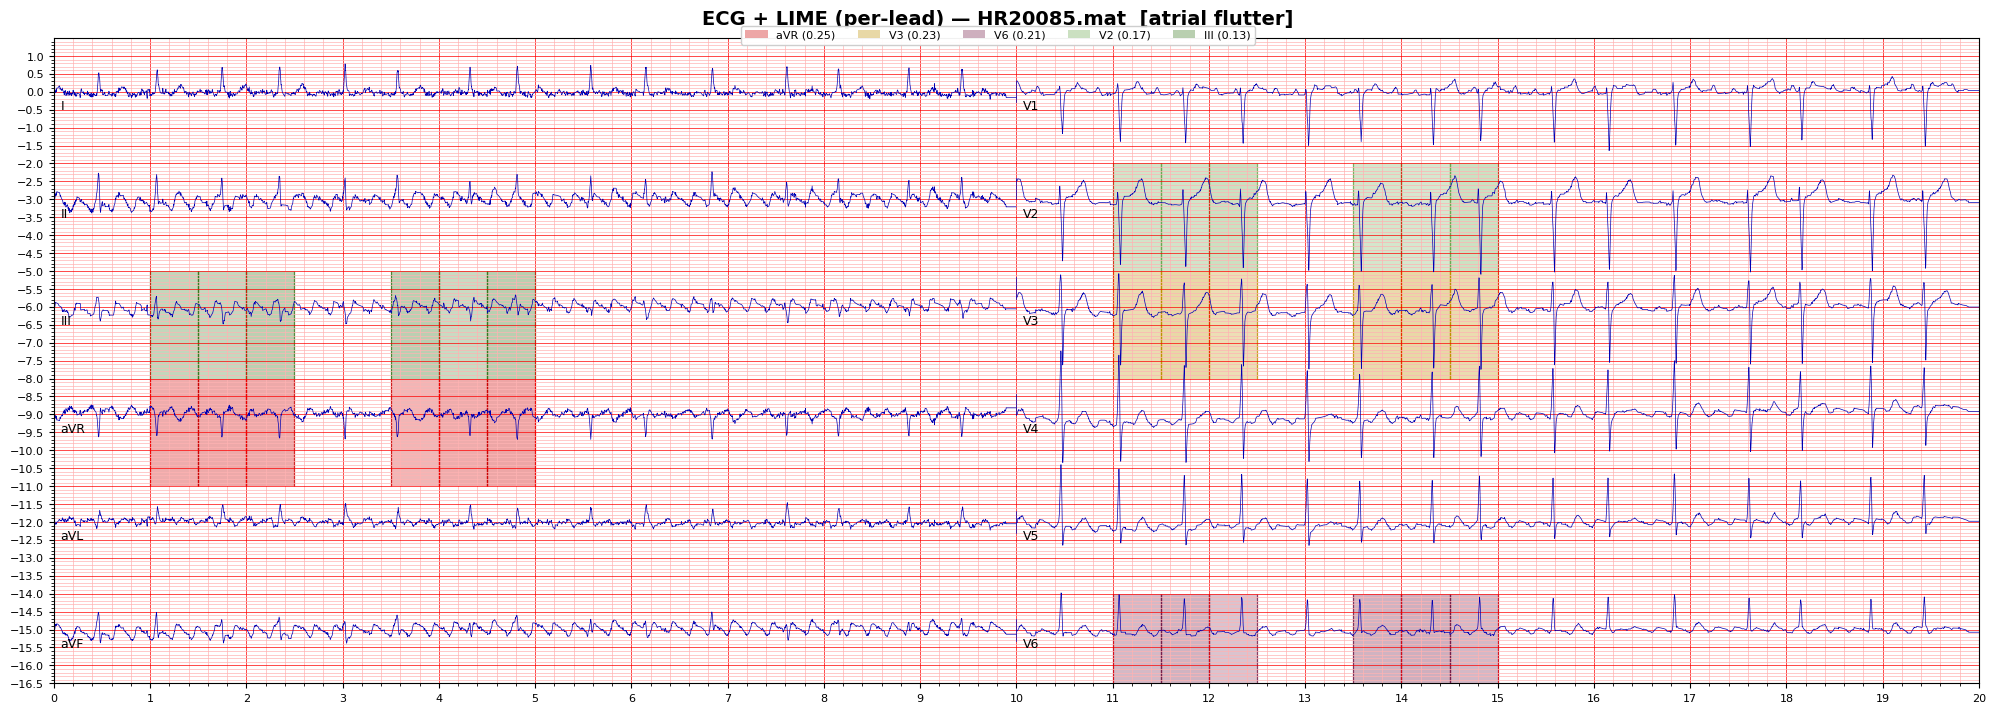

<Figure size 2000x600 with 0 Axes>

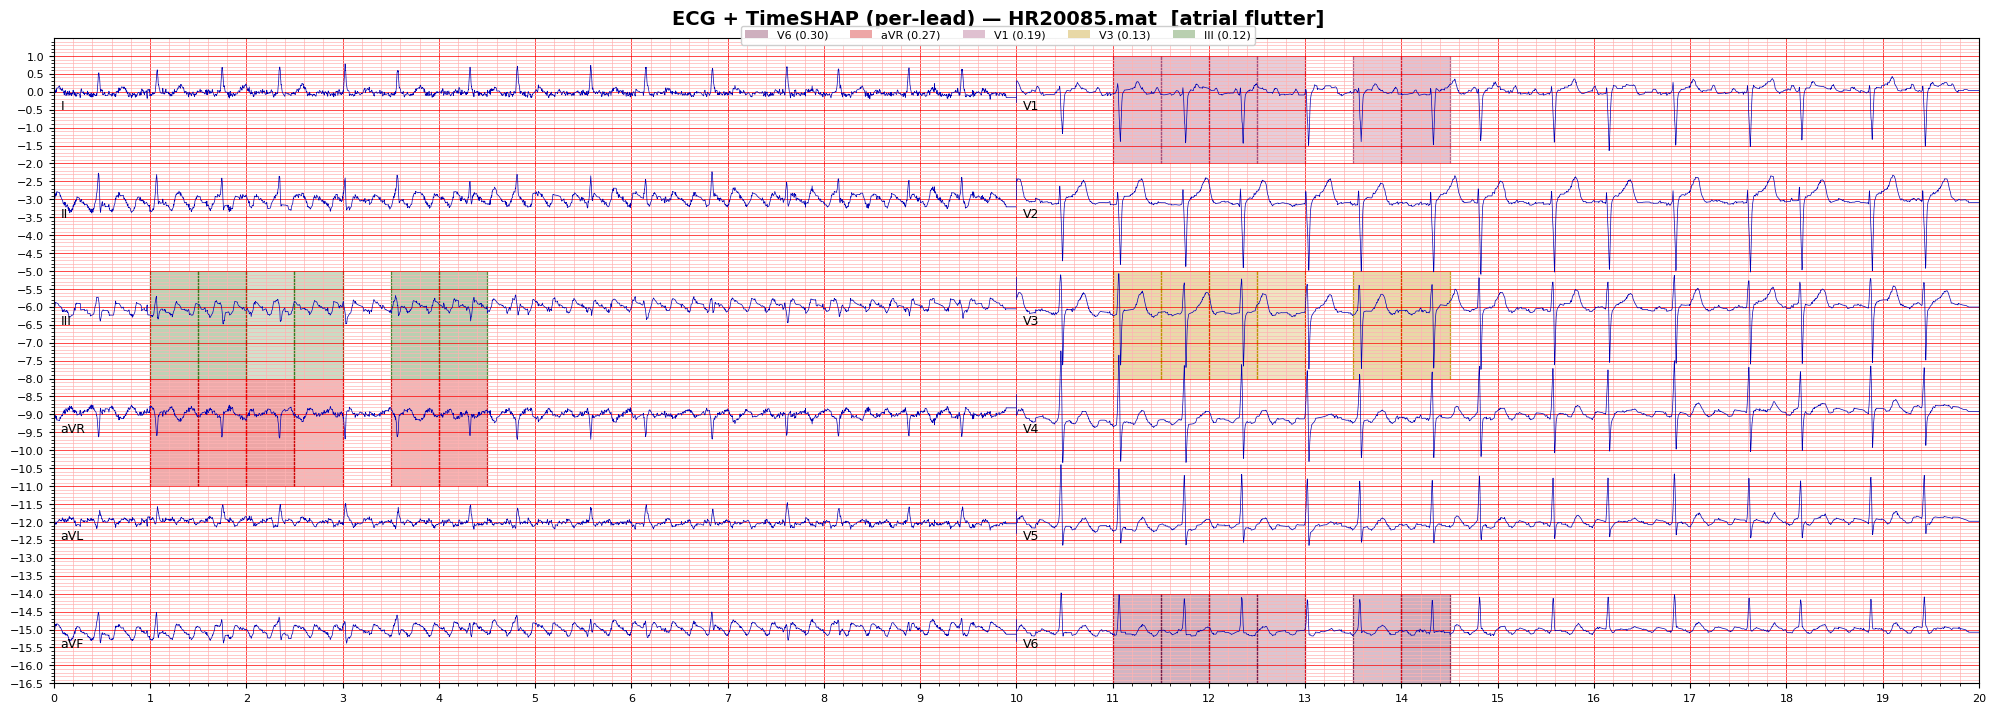

In [130]:
# pick one record from your df_lime_one (e.g., by val_idx)
val_i = int(df_lime_one.iloc[1]["val_idx"])
row_L = df_lime_one[df_lime_one["val_idx"] == val_i].iloc[0]
row_T = df_timeshap_one[df_timeshap_one["val_idx"] == val_i].iloc[0]

payload_L = payload_from_lime_row(row_L, label_for_title=row_L.get("group_class",""))
payload_T = payload_from_timeshap_row(row_T, label_for_title=row_T.get("group_class",""))
plot_from_payload(payload_L)  # method_label='LIME'
plot_from_payload(payload_T)  # method_label='TimeSHAP'


# TBC Add from here